In [ ]:
# This Notebook is for isolating the charts/information from analysis.ipynb into a more focused narrative, rather than general exploration
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# df is the clean data post cleaning and used for this report
# dirty_df is used only in ## Data Cleaning Summary to explain cleaning steps
df = pd.read_parquet('data/02_processed/03_cleaned_2025_tripdata.parquet')
dirty_df = pd.read_parquet('data/02_processed/02_prepared_2025_tripdata.parquet')

In [ ]:
# Color Palette

hue_order = ['member', 'casual']
my_palette = {
    'casual': '#d43434',
    'member': '#005d87',
    #'casual': '#ff8f41'    # 
    # 'member': '#4e79a7',   # Tableau blue
    # 'casual': '#e15759'    # Tableau red
    # 'member': '#ff7f0e', # original orange pairing
    # 'casual': '#1f77b4'  # original blue
}


# Style settings
sns.set_style('whitegrid')
plt.rcParams.update({
    'font.family': 'Arial', # 'Inter', 'Arial', 'DejaVu Sans', 'sans-serif'
    'font.size': 11,

    'grid.color': '#E5E5E5', # 'lightgray',
    'grid.linewidth': 0.8,

    'figure.dpi': 120,        # preview quality
    'savefig.dpi': 300,       # export quality
    'savefig.bbox': 'tight',
})

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

df["day_of_week"] = pd.Categorical(df["day_of_week"], categories=day_order, ordered=True)

## Data Cleaning Summary

In [ ]:
key_columns = ['ride_id', 'rideable_type', 'started_at', 'ended_at', 'member_casual']

print("Missing values in key columns:")
print(dirty_df[key_columns].isna().sum())


Missing values in key columns:
ride_id          0
rideable_type    0
started_at       0
ended_at         0
member_casual    0
dtype: int64


In [ ]:
# Check for duplicated data
print(f'{dirty_df.duplicated().sum()} duplicate rows in raw dataset')
print(f'{dirty_df.duplicated(subset=["ride_id"]).sum()} duplicate ride_ids in raw dataset')

0 duplicate rows in raw dataset
0 duplicate ride_ids in raw dataset


In [ ]:
# Check for invalid values, should be
# member_casual: member, casual
# rideable_type: classic_bike, electric_bike

print(dirty_df["member_casual"].value_counts(dropna=False))
print(dirty_df["rideable_type"].value_counts(dropna=False))

member_casual
member    3553497
casual    1999497
Name: count, dtype: int64
rideable_type
electric_bike    3604953
classic_bike     1948041
Name: count, dtype: int64


In [ ]:
# # Electric bike share for sub-60s rides vs overall
short_rides = dirty_df[dirty_df['ride_length_seconds'] < 60]
short_rides_60_120 = dirty_df[dirty_df['ride_length_seconds'].between(60, 120)]    



# results, 
# electric bikes are 99.99% of <60s rides
# electric bikes don't dominate the 60-120s range like the <60s range, matching the overall %


print("---Short rides (<60s) raw data---")
print(f"Electric: {short_rides['rideable_type'].value_counts(normalize=True)['electric_bike']:.2%}")
print(f"Overall electric %: {dirty_df['rideable_type'].value_counts(normalize=True)['electric_bike']:.2%}")

print("\n---Short rides (60-120s) raw data---")
print(f"Electric: {short_rides_60_120['rideable_type'].value_counts(normalize=True)['electric_bike']:.2%}")
print(f"Overall electric %: {dirty_df['rideable_type'].value_counts(normalize=True)['electric_bike']:.2%}")

---Short rides (<60s) raw data---
Electric: 99.99%
Overall electric %: 64.92%

---Short rides (60-120s) raw data---
Electric: 64.00%
Overall electric %: 64.92%


## Data Overview


In [ ]:
u_counts = df['member_casual'].value_counts()
OVERALL_PCT_CASUAL = u_counts['casual'] / u_counts.sum() * 100

print(f"Total rides: {u_counts.sum():,}")
print(f"Casual: {u_counts['casual']:,} ({OVERALL_PCT_CASUAL:.1f}%)")
print(f"Member: {u_counts['member']:,} ({100 - OVERALL_PCT_CASUAL:.1f}%)")

Total rides: 5,405,593
Casual: 1,920,483 (35.5%)
Member: 3,485,110 (64.5%)


In [ ]:
df.groupby(['member_casual', 'rideable_type'])['ride_id'].count()

member_casual  rideable_type
casual         classic_bike      672670
               electric_bike    1247813
member         classic_bike     1275359
               electric_bike    2209751
Name: ride_id, dtype: int64

In [ ]:
summary = df.groupby(['rideable_type', 'member_casual'], as_index=False).agg(
    avg_ride_length_minutes =('ride_length_minutes', 'mean'),
    median_ride_length_minutes=('ride_length_minutes', 'median'),
    ride_count=('ride_id','count')
)

summary['ride_count_mil']= summary['ride_count']/1000000
summary.head()

,rideable_type,member_casual,avg_ride_length_minutes,median_ride_length_minutes,ride_count,ride_count_mil
0,classic_bike,casual,39.481410,16.410667,672670,0.672670
1,classic_bike,member,14.681942,9.219600,1275359,1.275359
2,electric_bike,casual,14.899408,10.240933,1247813,1.247813
3,electric_bike,member,11.346528,8.498717,2209751,2.209751


In [ ]:
summary = df.groupby(['member_casual'], as_index=False).agg(
    avg_ride_length_minutes =('ride_length_minutes', 'mean'),
    median_ride_length_minutes=('ride_length_minutes', 'median'),
    ride_count=('ride_id','count')
)

summary['ride_count_mil']= summary['ride_count']/1_000_000

sns.barplot(data=summary,
            x='member_casual',
            y='ride_count_mil',
            errorbar=None,
            hue='member_casual',
            hue_order=hue_order,
            palette=my_palette,
            )

plt.title('Total Rides by User Type (2025 Divvy, Chicago)')
plt.xlabel("User Type")
plt.ylabel("Rides (Millions)")


plt.savefig("figures/total_rides_300dpi.png")
plt.show()

In [72]:
# years ridden
print(f'Fun Fact: In 2025 Divvy users rented bikes for a total of {df["ride_length_minutes"].sum() / 60 / 24 / 365:.2f} years!')


Fun Fact: In 2025 Divvy users rented bikes for a total of 169.23 years!


## How much of monthly ride volume is casual?

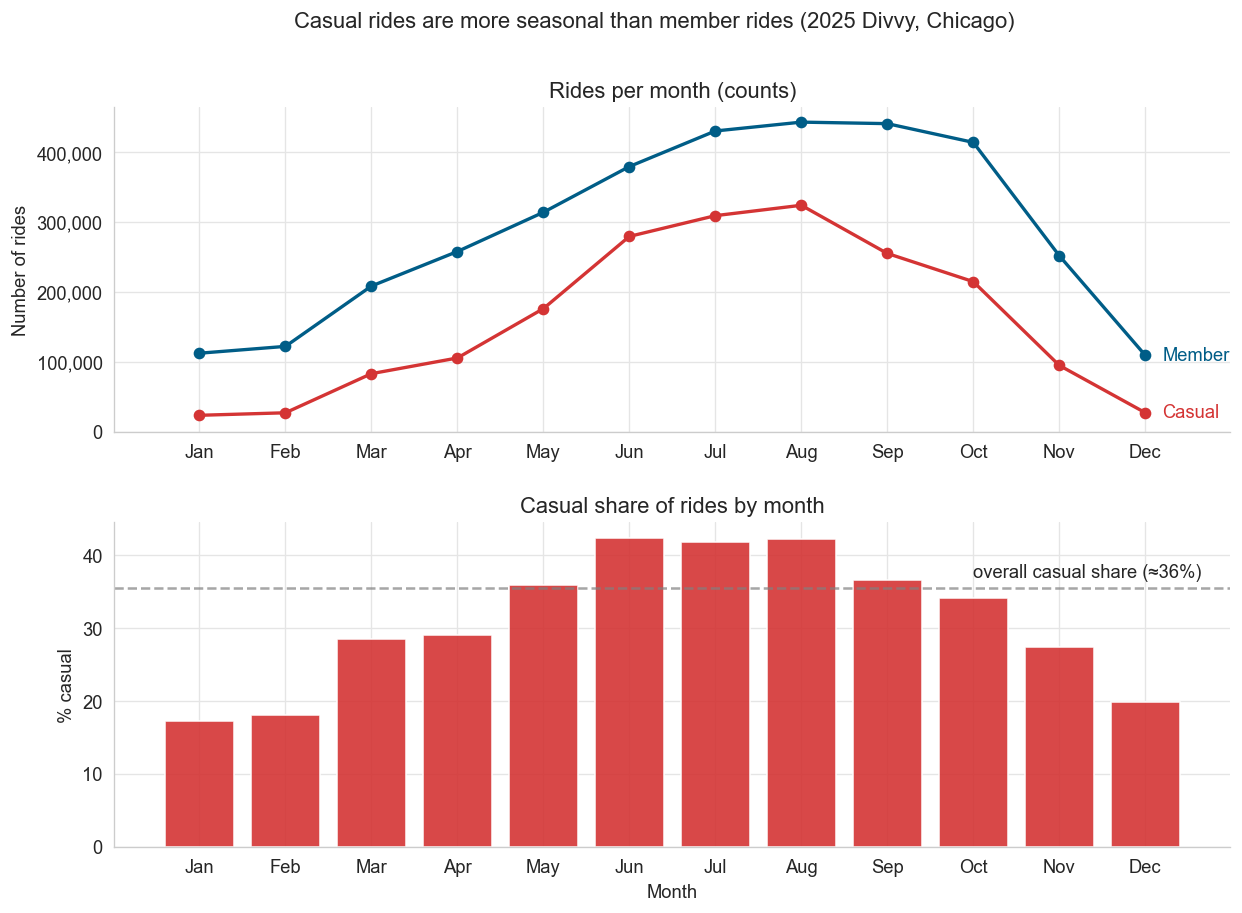

In [ ]:
monthly_counts = (df.groupby(["month", "member_casual"], as_index=False)
       .agg(n=("ride_id","size")))

monthly_pivot = monthly_counts.pivot(index="month", columns="member_casual", values="n").fillna(0)
monthly_pivot["total"] = monthly_pivot.sum(axis=1)
monthly_pivot["casual_pct"] = monthly_pivot["casual"] / monthly_pivot["total"] * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(monthly_pivot.index, monthly_pivot["member"], 
             label="member", 
             color=my_palette['member'],
             linewidth=2,
             marker='o')
axes[0].plot(monthly_pivot.index, monthly_pivot["casual"], 
             label="casual", 
             color=my_palette['casual'],
             linewidth=2,
             marker='o')
axes[0].set_ylim(0, None)
axes[0].tick_params(axis='x', labelbottom=True)
# Format y-axis with commas for thousands
axes[0].yaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))
axes[0].set_ylabel("Number of rides")
axes[0].set_title("Rides per month (counts)")
# axes[0].legend()

axes[1].bar(monthly_pivot.index, monthly_pivot["casual_pct"], 
            color=my_palette['casual'],
            alpha=0.9
            )
axes[1].set_ylabel("% casual")
axes[1].set_xlabel("Month")
axes[1].set_title("Casual share of rides by month")

axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])


axes[1].axhline(OVERALL_PCT_CASUAL, linestyle="--", color="gray", alpha=0.7)
axes[1].annotate(
    "overall casual share (≈36%)",
    #'overall % casual (≈36%)',
    xy=(2, 36), xytext=(10, 37),
)

## Member Casual line labels, gets last point to be at end of line
axes[0].text(12.2, monthly_pivot['casual'].iloc[-1], 
             'Casual', va='center', color=my_palette['casual'])
axes[0].text(12.2, monthly_pivot['member'].iloc[-1], 
             'Member', va='center', color=my_palette['member'])

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.subplots_adjust(hspace=0.28)

# plt.tight_layout()
plt.suptitle('Casual rides are more seasonal than member rides (2025 Divvy, Chicago)')
# 'Monthly Ride Counts and Casual Share (2025 Divvy, Chicago)')#, y=1.02)
# axes[0].plot(p.index, p["member"], label="member", color=my_palette['member'], linewidth=2.5, marker="o")
# axes[0].plot(p.index, p["casual"], label="casual", color=my_palette['casual'], linewidth=2.5, marker="o")
plt.savefig("figures/monthly_use_300dpi.png")
plt.show()

In [74]:
monthly_pivot.reset_index()

member_casual,month,casual,member,total,casual_pct
0,1,23453,112352,135805,17.269615
1,2,27051,122118,149169,18.134465
2,3,83064,208500,291564,28.489114
3,4,105528,257962,363490,29.031885
4,5,176162,314091,490253,35.932875
5,6,279570,379609,659179,42.411849
6,7,309293,430535,739828,41.806068
7,8,324165,443214,767379,42.243142
8,9,255223,441046,696269,36.655804
9,10,214849,414231,629080,34.152890


In [75]:
# 1=Jan, 2=Feb, 3=Mar, 4=Apr, 5=May, 6=Jun, 7=Jul, 8=Aug, 9=Sep, 10=Oct, 11=Nov, 12=Dec
may_sep_casual_pct = monthly_pivot.loc[5:9, "casual"].sum() / monthly_pivot["casual"].sum()
may_sep_member_pct = monthly_pivot.loc[5:9, "member"].sum() / monthly_pivot["member"].sum()
jun_aug_casual_pct = monthly_pivot.loc[6:8, "casual"].sum() / monthly_pivot["casual"].sum()

# dec-feb
dec_feb_casual = (monthly_pivot.loc[12, "casual"] + monthly_pivot.loc[1:2, "casual"].sum()) / monthly_pivot["casual"].sum()
dec_feb_member = (monthly_pivot.loc[12, "member"] + monthly_pivot.loc[1:2, "member"].sum()) / monthly_pivot["member"].sum()

dec_feb_member_by_casual = dec_feb_member / dec_feb_casual

print(f'{may_sep_casual_pct:.2%} of casual rides May-Sep')
print(f'{may_sep_member_pct:.2%} of member rides May-Sep')
print(f'{jun_aug_casual_pct:.2%} of casual rides Jun-Aug')
print(f'{dec_feb_casual:.2%} of casual rides Dec-Feb')
print(f'{dec_feb_member:.2%} of member rides Dec-Feb')
print(f'{dec_feb_member_by_casual:.2f} member to casual ratio Dec-Feb')

# may_sep_member_pct = p.loc[5:9, "member"].sum() / p["member"].sum()
# jun_aug_member_pct = p.loc[6:8, "member"].sum() / p["member"].sum()
# print(f'{may_sep_member_pct:.2%} of member rides May-Sep')
# print(f'{jun_aug_member_pct:.2%} of member rides Jun-Aug')

70.00% of casual rides May-Sep
57.63% of member rides May-Sep
47.54% of casual rides Jun-Aug
4.05% of casual rides Dec-Feb
9.87% of member rides Dec-Feb
2.44 member to casual ratio Dec-Feb


## When do Users ride?
- there is a strong commuter pattern for Members


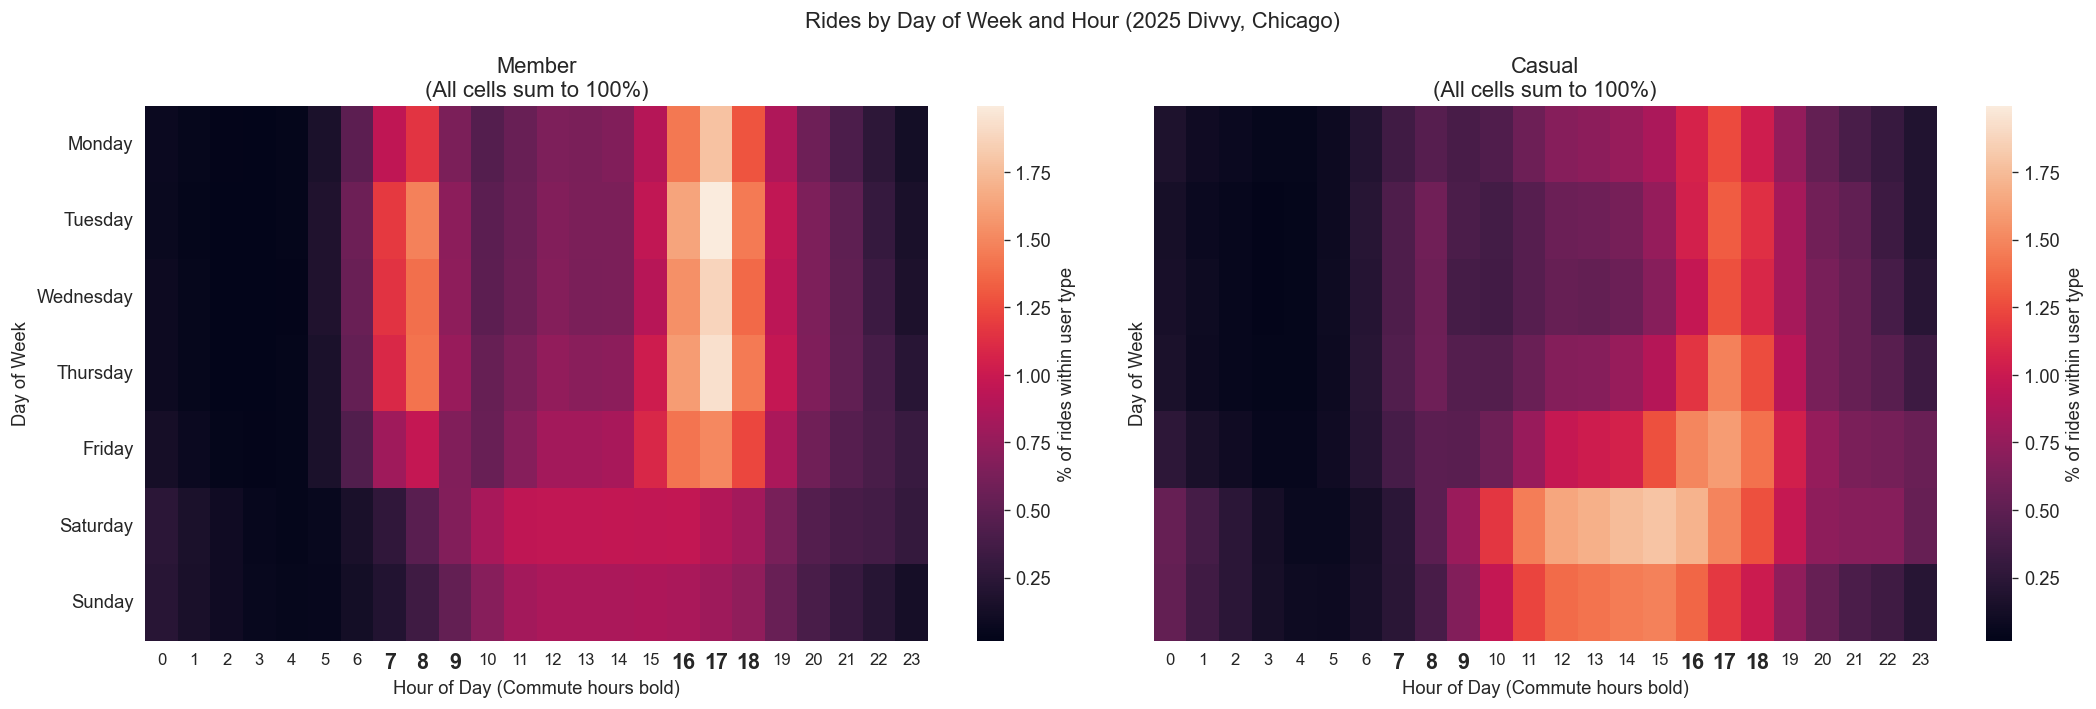

In [ ]:
# normalized by group percentage

# Calculations for heatmap
pivot_member = df[df['member_casual']=='member'].pivot_table(
    index='day_of_week', columns='start_hour', values='ride_id', aggfunc='count')
pivot_casual = df[df['member_casual']=='casual'].pivot_table(
    index='day_of_week', columns='start_hour', values='ride_id', aggfunc='count')

# Rides at (Day X, Hour Y)/(Total Rides) *100
pivot_member_pct = (pivot_member / pivot_member.to_numpy().sum()) * 100
pivot_casual_pct = (pivot_casual / pivot_casual.to_numpy().sum()) * 100

vmin = min(pivot_member_pct.min().min(), pivot_casual_pct.min().min())
vmax = max(pivot_member_pct.max().max(), pivot_casual_pct.max().max())


# Plotting Area
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
sns.heatmap(pivot_member_pct, ax=axes[0], square=False, cbar_kws={'label': '% of rides within user type'}, vmin=vmin, vmax=vmax) 
axes[0].set_title('Member\n(All cells sum to 100%)')
sns.heatmap(pivot_casual_pct, ax=axes[1], square=False, cbar_kws={'label': '% of rides within user type'}, vmin=vmin, vmax=vmax) # \n(all cells sum to 100%)
axes[1].set_title('Casual\n(All cells sum to 100%)')
for ax in axes:
    ax.set_xlabel('Hour of Day (Commute hours bold)')
    ax.set_ylabel('Day of Week')

    ax.tick_params(axis='x', labelsize=10)
    for label in ax.get_xticklabels():
        if label.get_text() in ['7', '8', '9', '16', '17', '18']:
            label.set_fontsize(13)
            label.set_fontweight('bold')

plt.suptitle('Rides by Day of Week and Hour (2025 Divvy, Chicago)')
plt.tight_layout()#rect=[0, 0, 1, 0.95])

plt.savefig("figures/heatmap_300dpi.png")
plt.show()

In [78]:
# % of member commute ride count that happens during peak commute hours/days


# Info for heatmap, 
# below kpi of heatmap

# Commute Hours defined as: 7-9 am, 4-6pm Mon-Fri
COMMUTE_HOURS = [7, 8, 9, 16, 17, 18]
WEEKDAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
pivot_member_commute = pivot_member.loc[WEEKDAYS, COMMUTE_HOURS]
pivot_casual_commute = pivot_casual.loc[WEEKDAYS, COMMUTE_HOURS]


pct_member_commute_hours = pivot_member_commute.to_numpy().sum()/pivot_member.to_numpy().sum() *100
pct_casual_commute_hours = pivot_casual_commute.to_numpy().sum()/pivot_casual.to_numpy().sum() *100

times_more_concentrated = pct_member_commute_hours / pct_casual_commute_hours


print('pct member during commute hours count:', pct_member_commute_hours)
print('pct casual during commute hours count:', pct_casual_commute_hours)

print('members are X ', times_more_concentrated.round(2), ' times more concentrated around commute hours than casual riders')

print('casual commute hour rides: ', pivot_casual_commute.to_numpy().sum())
print('member commute hour rides: ', pivot_member_commute.to_numpy().sum())


pct member during commute hours count: 38.58190989667471
pct casual during commute hours count: 25.36377567518171
members are X  1.52  times more concentrated around commute hours than casual riders
casual commute hour rides:  487107
member commute hour rides:  1344622


In [79]:
# Info for heatmap, 
# below kpi of heatmap

pivot_member_weekend = pivot_member.loc[['Saturday', 'Sunday']]
pivot_casual_weekend = pivot_casual.loc[['Saturday', 'Sunday']]


pct_member_weekend = pivot_member_weekend.to_numpy().sum()/pivot_member.to_numpy().sum() *100
pct_casual_weekend = pivot_casual_weekend.to_numpy().sum()/pivot_casual.to_numpy().sum() *100

times_more_concentrated = pct_casual_weekend / pct_member_weekend 


print('pct member during weekend count:', pct_member_weekend)
print('pct casual during weekend count:', pct_casual_weekend)

print('Casuals are X ', times_more_concentrated.round(2), ' times more concentrated around weekends than Member riders')

pct member during weekend count: 23.375790147226343
pct casual during weekend count: 37.20454698115005
Casuals are X  1.59  times more concentrated around weekends than Member riders


## How long they ride

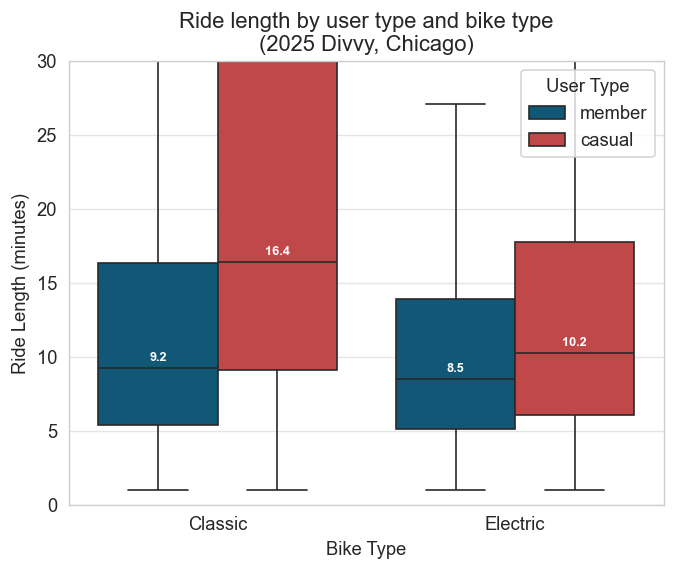

In [ ]:
box_plot = sns.boxplot(
    data=df,
    x="rideable_type",
    y="ride_length_minutes",
    hue="member_casual",
    showfliers=False,
    order=["classic_bike", "electric_bike"],
    hue_order=hue_order,
    palette=my_palette,
)

# get medians
medians = df.groupby(['rideable_type', 'member_casual'])['ride_length_minutes'].median()
vertical_offset = df['ride_length_minutes'].median() * 0.05

# draw medians on each box median line
for i, rideable in enumerate(["classic_bike", "electric_bike"]):
    for j, member_type in enumerate(hue_order):
        median_val = medians[rideable, member_type]
        n_hue = len(hue_order)
        x = i - 0.2 + 0.4 * j
        box_plot.text(x, median_val + vertical_offset, f"{median_val:.1f}",
                      horizontalalignment='center', size='x-small', color='w', weight='semibold')

plt.xticks([0,1], ['Classic', 'Electric'])
plt.title("Ride length by user type and bike type\n(2025 Divvy, Chicago)")
plt.ylabel("Ride Length (minutes)")
plt.xlabel("Bike Type")
plt.legend().set_title('User Type')
plt.ylim(0, 30)

plt.savefig("figures/ride_length_boxplot_300dpi.png")
plt.show()

In [81]:
df.groupby(['rideable_type', 'member_casual'])['ride_length_minutes'].count()

rideable_type  member_casual
classic_bike   casual            672670
               member           1275359
electric_bike  casual           1247813
               member           2209751
Name: ride_length_minutes, dtype: int64

In [82]:
# IQR for casual classic riders
casual_classic = df[(df['member_casual'] == 'casual') & (df['rideable_type'] == 'classic_bike')]
casual_classic['ride_length_minutes'].quantile(0.75) - casual_classic['ride_length_minutes'].quantile(0.25)

np.float64(22.274375)

In [83]:
# Q1 and Q3, IQR bounds for casual classic riders
casual_classic['ride_length_minutes'].quantile([0.25, 0.75])

0.25     9.082125
0.75    31.356500
Name: ride_length_minutes, dtype: float64

## Long rides are mostly casual riders

In [84]:
# values in minutes

megalist = []

# Creates longrides: df that stores the count of rides > X minutes, for each minute from 0-60
for x in range(0, 61, 1):
    df_p = df[df['ride_length_minutes'] >= x].copy()

    summary = (df_p.groupby(['member_casual', 'rideable_type'], as_index=False)
           .agg(long_ride_count=("ride_id","size")))

    member_count = summary[summary['member_casual'] == 'member']['long_ride_count'].sum()
    casual_count = summary[summary['member_casual'] == 'casual']['long_ride_count'].sum()
    casual_classic_count = summary[(summary['member_casual'] == 'casual') & 
                                   (summary['rideable_type'] == 'classic_bike')]['long_ride_count'].sum()
    
    pct_casual_classic_count = (summary[(summary['member_casual'] == 'casual') & (summary['rideable_type'] == 'classic_bike')]['long_ride_count'].sum() / casual_count * 100).round(2)
    
    
    total = member_count + casual_count

    if total == 0:
        continue
    
    member_count_pct = (member_count / total * 100).round(2)
    casual_count_pct = (casual_count / total * 100).round(2)
    casual_classic_count_pct = (casual_classic_count / total * 100).round(2)


    megalist.append({
        'time_threshold': x,
        'member_count': member_count,
        'casual_count': casual_count,
        'member_count_pct': member_count_pct,
        'casual_count_pct': casual_count_pct,
        'casual_classic_count_pct': casual_classic_count_pct,
        'total_count': total
    })

longrides = pd.DataFrame(megalist)

In [85]:
longrides['total_count_millions'] = longrides['total_count'] / 1000000

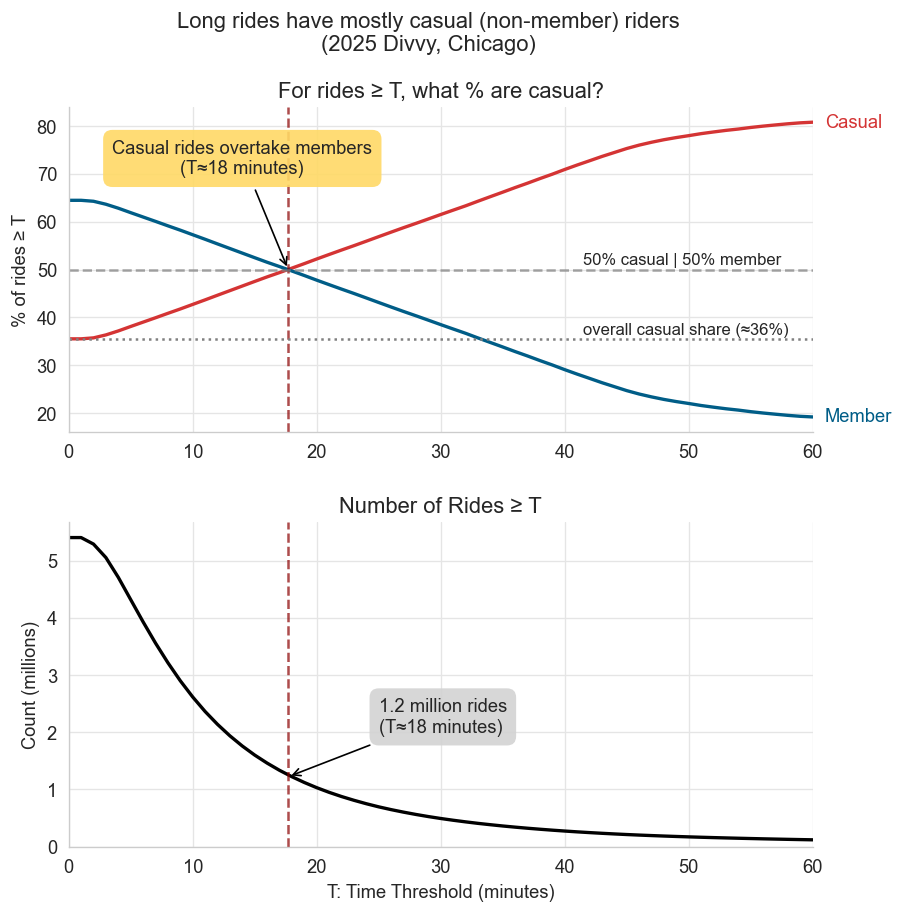

In [86]:
# Question: for rides >= T, what % are casual?

#note: my current estimate of the intercept is 17.7, not 18, due to data points being at whole minutes, and the crossing happening between 17 and 18
majority_intersect = 17.7

# figsize=(10,6)

fig, axes = plt.subplots(2, 1, figsize=(8,8), sharex=True)


sns.lineplot(data=longrides, x="time_threshold", y="casual_count_pct", 
             ax=axes[0], legend=False, 
             color=my_palette['casual'], linewidth=2)
sns.lineplot(data=longrides, x="time_threshold", y="member_count_pct", 
             ax=axes[0], legend=False,
             color=my_palette['member'], linewidth=2)
sns.lineplot(data=longrides, x="time_threshold", y="total_count_millions", 
             ax=axes[1], legend=False, 
             color="black", linewidth=2)

axes[0].axvline(majority_intersect, color="darkred", linestyle="--", alpha=0.7)
axes[1].axvline(majority_intersect, color="darkred", linestyle="--", alpha=0.7)

# ax.text(55, casual_share.iloc[-1], "Casual", va="center")
# ax.text(55, member_share.iloc[-1], "Member", va="center")

# combine legends (only from ax1)
# axes[0].legend(loc="best")

axes[0].text(x=41.5, y=51, s="50% casual | 50% member", fontsize=10)
axes[0].axhline(50, color="grey", linestyle="--", alpha=0.7) # majority line
axes[0].text(x=41.5, y=OVERALL_PCT_CASUAL + 1, s="overall casual share (≈36%)", fontsize=10)
axes[0].axhline(OVERALL_PCT_CASUAL, color="grey", linestyle=":") # overall casual % (T=0)
axes[0].annotate(
    "Casual rides overtake members\n(T≈18 minutes)",
    ha='center',
    xy=(majority_intersect, 50), xytext=(14, 70),#4, 70),
    arrowprops=dict(arrowstyle="->", color='black'),
    # bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=1)
    bbox=dict(facecolor='#FFD966', alpha=0.9, edgecolor='none', boxstyle="round,pad=0.5")
)
axes[1].annotate(
    "1.2 million rides\n(T≈18 minutes)",
    # 1,223,302 rides at >= 18 minutes",
    xy=(majority_intersect, 1.223000), xytext=(25, 2),
    arrowprops=dict(arrowstyle="->", color='black'),
    bbox=dict(facecolor='lightgray', alpha=0.9, edgecolor='none', boxstyle="round,pad=0.5")
    # bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", alpha=1)
)

#plt.text(x=20, y=5, s="majority", fontsize=12, color='red')#, ax=axes[0])

# axes[0].legend().set_title('User Type')



for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


## Member Casual line labels, gets last point to be at end of line
axes[0].text(61, longrides[longrides['time_threshold']==60]['casual_count_pct'].values[0], 
             'Casual', va='center', color=my_palette['casual'])
axes[0].text(61, longrides[longrides['time_threshold']==60]['member_count_pct'].values[0], 
             'Member', va='center', color=my_palette['member'])


axes[0].set_xlim(0, 60)
axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, None)

#fig.suptitle('Percentage of Rides ≥ T')
axes[0].tick_params(axis='x', labelbottom=True)
axes[0].set_title('For rides ≥ T, what % are casual?')
axes[0].set_xlabel('T: Time Threshold (minutes)')
axes[0].set_ylabel('% of rides ≥ T')
                    # '% of rides ≥ T that are casual')
                    #'Percentage of casual rides ≥ T')
axes[1].set_title('Number of Rides ≥ T')
axes[1].set_xlabel('T: Time Threshold (minutes)')
axes[1].set_ylabel('Count (millions)')
# axes[1].set_yscale("log")
# plt.tight_layout()

# distance between the two plots
plt.subplots_adjust(hspace=0.28)

plt.suptitle('Long rides have mostly casual (non-member) riders\n(2025 Divvy, Chicago)')#y=1.02
             #'Casual share increases with ride duration (2025 Divvy, Chicago)')

plt.savefig("figures/tailbehaviour_300dpi.png")# bbox_inches="tight")
plt.show()

In [87]:
# Dropping columns for a focused longrides_f
# 'member_count_pct', 
# 'total_count',
# 'total_count_millions'

longrides_f = longrides[['time_threshold', 'member_count', 'casual_count', 
       'casual_count_pct', 'casual_classic_count_pct', ]]

In [88]:
longrides_f[longrides_f['time_threshold'].between(17,19)]

,time_threshold,member_count,casual_count,casual_count_pct,casual_classic_count_pct
17,17,676153,659255,49.37,24.41
18,18,607996,615306,50.30,25.29
19,19,547368,575107,51.24,26.19


In [89]:
longrides_f.head()

,time_threshold,member_count,casual_count,casual_count_pct,casual_classic_count_pct
0,0,3485110,1920483,35.53,12.44
1,1,3485110,1920483,35.53,12.44
2,2,3400648,1890834,35.73,12.56
3,3,3217834,1837369,36.35,12.94
4,4,2958722,1750989,37.18,13.53


In [ ]:
# Are casual rides the majority of the tail across seasons?

season_labels = {1: 'Q1 (Jan-Mar)', 2: 'Q2 (Apr-Jun)', 3: 'Q3 (Jul-Sep)', 4: 'Q4 (Oct-Dec)'}
season_colors = {1: '#4e79a7', 2: '#f28e2b', 3: "#bb2326", 4: '#76b7b2'}

megalist_seasonal = []

for quarter in [1, 2, 3, 4]:
    df_quarter = df[df['start_quarter'] == quarter]
    
    for x in range(0, 61, 1):
        df_p = df_quarter[df_quarter['ride_length_minutes'] >= x]
        
        member_count = (df_p['member_casual'] == 'member').sum()
        casual_count = (df_p['member_casual'] == 'casual').sum()
        total = member_count + casual_count
        
        if total == 0:
            continue
            
        casual_pct = (casual_count / total * 100).round(2)

        megalist_seasonal.append({
            'quarter': quarter, 
            'time_threshold': x, 
            'member_count': member_count, 
            'casual_count': casual_count, 
            'casual_count_pct': casual_pct, 
            'total_count': total
        })


seasonal = pd.DataFrame(megalist_seasonal)

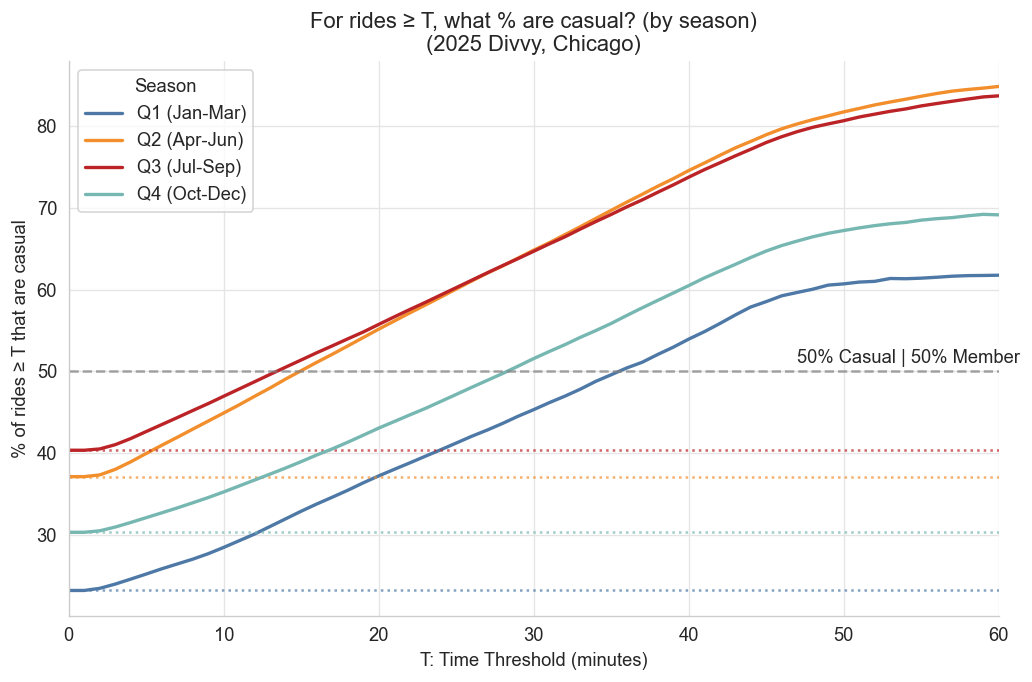

In [ ]:
# Get quarter baselines (T=0 casual %) for baselines
# dict(zip(keys, values))
baselines = dict(zip(
    seasonal[seasonal['time_threshold'] == 0]['quarter'],
    seasonal[seasonal['time_threshold'] == 0]['casual_count_pct']
))


# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

for quarter in [1, 2, 3, 4]:
    df_quarter = seasonal[seasonal['quarter'] == quarter]
    ax.plot(df_quarter['time_threshold'], df_quarter['casual_count_pct'],
            label=season_labels[quarter], color=season_colors[quarter],
            linewidth=2)
    
    ax.axhline(baselines[quarter], color=season_colors[quarter], linestyle=':', alpha=0.7)

ax.axhline(50, color='grey', linestyle='--', alpha=0.7) # majority line
ax.annotate('50% Casual | 50% Member', xy=(2, 50), xytext=(47, 51))

ax.set_title('For rides ≥ T, what % are casual? (by season)\n(2025 Divvy, Chicago)')
ax.set_xlabel('T: Time Threshold (minutes)')
ax.set_ylabel('% of rides ≥ T that are casual')
ax.legend(title='Season')


# plt.tight_layout()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 60)

plt.savefig("figures/seasonal_tailbehaviour_300dpi.png")
plt.show()

In [ ]:
seasonal_table = []
for quarter in [1, 2, 3, 4]:
    df_quarter = seasonal[seasonal['quarter'] == quarter]
    cross = df_quarter[df_quarter['casual_count_pct'] >= 50]
    threshold = cross['time_threshold'].iloc[0] if not cross.empty else None

    if not cross.empty:
        threshold = cross['time_threshold'].iloc[0]
    else:
        threshold = None

    seasonal_table.append({
        'Season': season_labels[quarter],
        'Baseline casual %': baselines[quarter],
        'Casual majority threshold (min)': threshold
    })

pd.DataFrame(seasonal_table)

,Season,Baseline casual %,Casual majority threshold (min)
0,Q1 (Jan-Mar),23.17,36
1,Q2 (Apr-Jun),37.10,15
2,Q3 (Jul-Sep),40.33,14
3,Q4 (Oct-Dec),30.29,29


In [ ]:
## test

# Are casual rides the majority of the tail across months?

month_labels = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

megalist_monthly = []

for month in range(1, 13):
    df_month = df[df['month'] == month]
    
    for x in range(0, 61, 1):
        df_p = df_month[df_month['ride_length_minutes'] >= x]
        
        member_count = (df_p['member_casual'] == 'member').sum()
        casual_count = (df_p['member_casual'] == 'casual').sum()
        total = member_count + casual_count
        
        if total == 0:
            continue
            
        casual_pct = round(casual_count / total * 100, 2)

        megalist_monthly.append({
            'month': month,
            'month_label': month_labels[month],
            'time_threshold': x,
            'member_count': member_count,
            'casual_count': casual_count,
            'casual_count_pct': casual_pct,
            'total_count': total
        })

monthly_tail = pd.DataFrame(megalist_monthly)

In [ ]:
# Get month baselines (T=0 casual %) for baselines
baselines = dict(zip(
    monthly_tail[monthly_tail['time_threshold'] == 0]['month'],
    monthly_tail[monthly_tail['time_threshold'] == 0]['casual_count_pct']
))

month_colors = {
    1: '#4e79a7', 2: '#f28e2b', 3: '#e15759', 4: '#76b7b2',
    5: '#59a14f', 6: '#edc948', 7: '#b07aa1', 8: '#ff9da7',
    9: '#9c755f', 10: '#bab0ab', 11: '#1f77b4', 12: '#d62728'
}

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))

for month in range(1, 13):
    df_month = monthly_tail[monthly_tail['month'] == month]
    ax.plot(
        df_month['time_threshold'],
        df_month['casual_count_pct'],
        label=month_labels[month],
        color=month_colors[month],
        linewidth=2
    )
    
    ax.axhline(
        baselines[month],
        color=month_colors[month],
        linestyle=':',
        alpha=0.5
    )

ax.axhline(50, color='grey', linestyle='--', alpha=0.7)
ax.annotate('50% Casual | 50% Member', xy=(2, 50), xytext=(47, 51))

ax.set_title('For rides ≥ T, what % are casual? (by month)\n(2025 Divvy, Chicago)')
ax.set_xlabel('T: Time Threshold (minutes)')
ax.set_ylabel('% of rides ≥ T that are casual')
ax.legend(title='Month', ncol=2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0, 60)

plt.savefig("figures/monthly_tailbehaviour_300dpi.png")
plt.show()